In [1]:
import torch 
from torch import nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import make_circles

In [3]:
x,y=make_circles(1000,noise=0.03)

In [4]:
x

array([[-0.65029086,  0.41841251],
       [ 0.92148535, -0.35510391],
       [-0.85142884, -0.56073767],
       ...,
       [-0.21677797, -1.01435308],
       [ 0.94323213,  0.25853009],
       [-0.19155703,  0.79896031]])

In [5]:
data=pd.DataFrame({"x1":x[:,0],"x2":x[:,1],"label":y})

In [6]:
data

,x1,x2,label
0,-0.650291,0.418413,1
1,0.921485,-0.355104,0
2,-0.851429,-0.560738,0
3,0.788294,0.547595,0
4,0.050990,-0.780108,1
...,...,...,...
995,-0.284610,-1.003651,0
996,0.031326,-0.835971,1
997,-0.216778,-1.014353,0
998,0.943232,0.258530,0


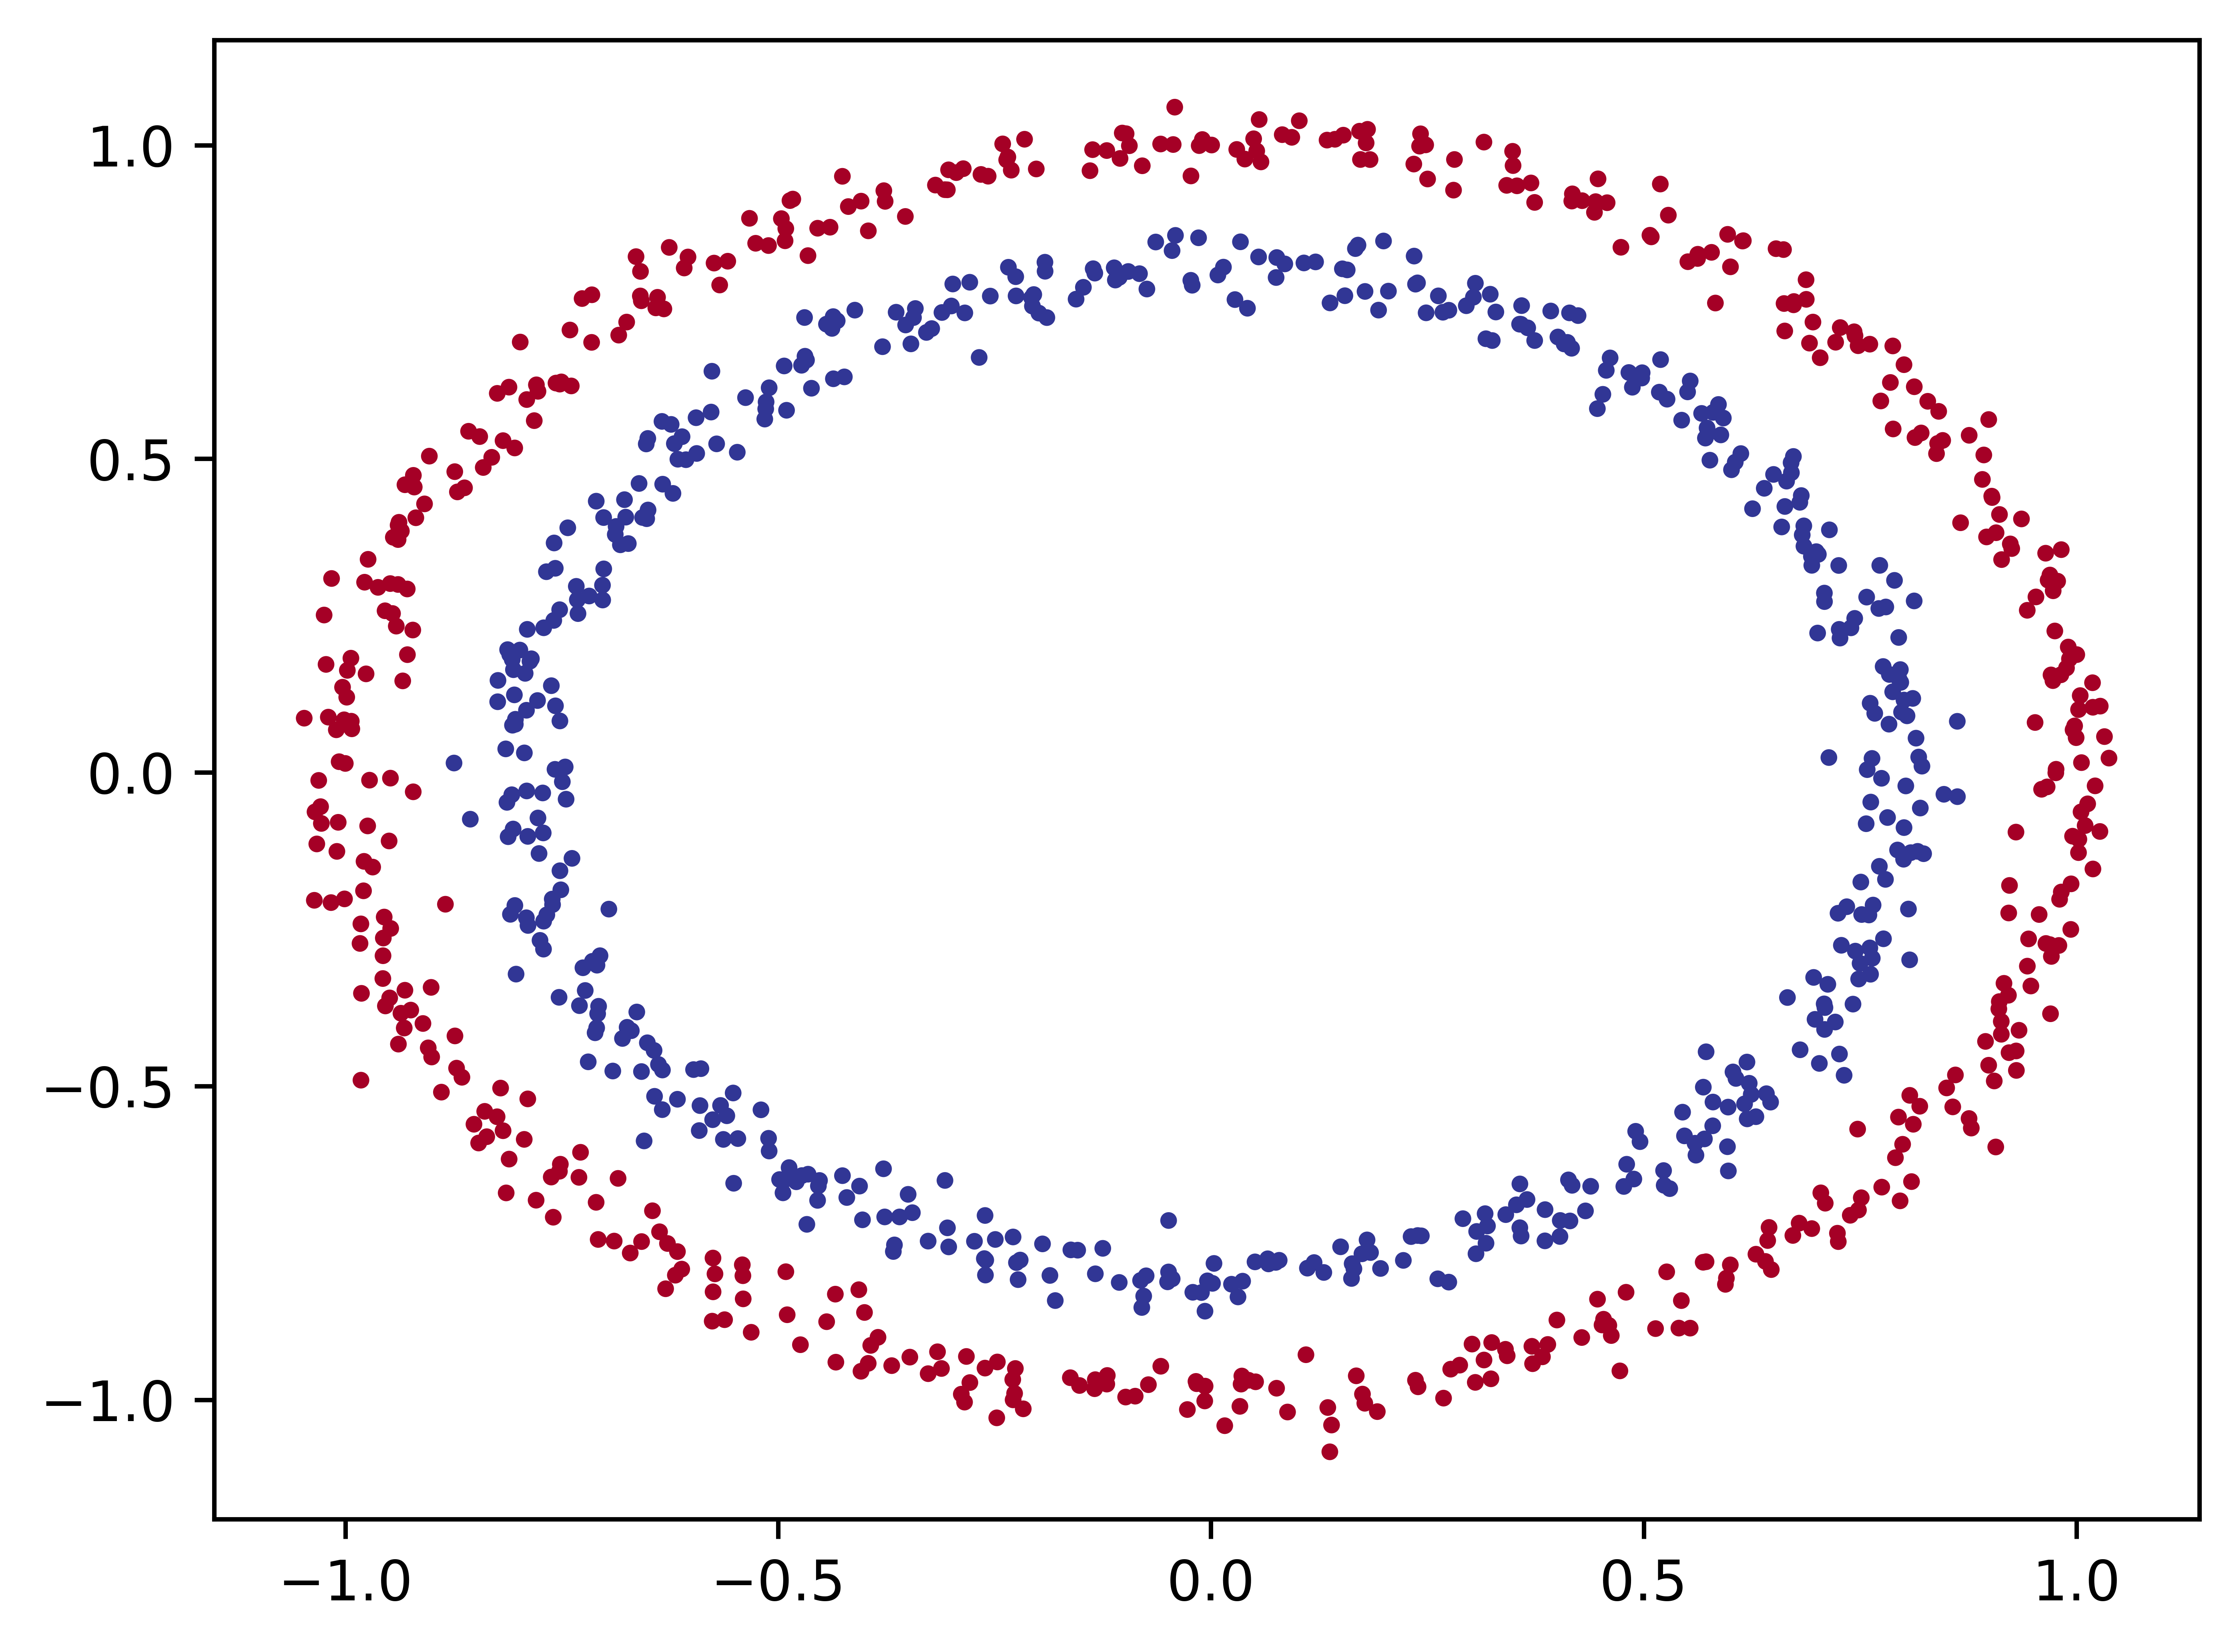

In [7]:
plt.figure(dpi=1000)
plt.scatter(data['x1'],data['x2'],cmap=plt.cm.RdYlBu,c=y,s=4)

In [8]:
model=nn.Sequential(
    nn.Linear(in_features=2,out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128,out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256,out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128,out_features=1)
).to('mps')
                 

In [9]:
model.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.2015,  0.2550],
                      [-0.0864, -0.5911],
                      [ 0.0528, -0.3604],
                      [ 0.6547,  0.5755],
                      [ 0.4193, -0.2201],
                      [ 0.0353,  0.5177],
                      [ 0.5086, -0.1286],
                      [-0.2105, -0.4180],
                      [-0.3111, -0.4781],
                      [-0.5701, -0.1280],
                      [-0.5988,  0.6056],
                      [ 0.4346,  0.1664],
                      [ 0.5034,  0.0217],
                      [ 0.3478, -0.3065],
                      [-0.0722,  0.2903],
                      [-0.4315,  0.6916],
                      [-0.4022, -0.4010],
                      [ 0.4071, -0.0448],
                      [-0.1742, -0.1161],
                      [-0.0163, -0.5099],
                      [-0.4445,  0.4359],
                      [-0.6685,  0.3445],
                      [ 0.3227,  0.5657],
        

In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)
x_train.shape
x_train=torch.from_numpy(x_train)
y_train=torch.from_numpy(y_train)
x_test=torch.from_numpy(x_test)
y_test=torch.from_numpy(y_test)
x_train=x_train.type(torch.float32).to('mps')
y_train=y_train.type(torch.float32).to('mps')
x_test=x_test.type(torch.float32).to('mps')
y_test=y_test.type(torch.float32).to('mps')
print(x_train)
loss_fn=nn.BCEWithLogitsLoss()
optimizer=torch.optim.SGD(params=model.parameters(),lr=0.01)

tensor([[ 0.1548,  0.7600],
        [-0.7531, -0.3584],
        [-0.9495, -0.1092],
        ...,
        [-0.6519,  0.4045],
        [-0.2785, -0.9725],
        [-0.6215,  0.4449]], device='mps:0')


In [13]:
def acc(y_true, y_pred):
    """
    Computes accuracy for binary classification.

    Args:
    y_true (torch.Tensor): Ground truth labels (shape: [batch_size]).
    y_pred (torch.Tensor): Predicted labels (shape: [batch_size]).

    Returns:
    float: Accuracy percentage (0-100%).
    """
    y_true = y_true.view(-1).to(torch.float32)  # Ensure correct shape
    y_pred = y_pred.view(-1).to(torch.float32)  # Ensure correct shape

    correct = (y_true == y_pred).sum().item()  # Count correct predictions
    total = y_true.size(0)  # Get the batch size

    return (correct / total) * 100  # Accuracy as a

In [14]:
epochs=4000
l=[]
a=[]
for epoch in range(epochs):

    model.train()
    y_logits=model(x_train)
    loss=loss_fn(y_logits.squeeze(),y_train)
    l.append(loss.to('cpu').detach().numpy())
    
    y_pred=torch.round(torch.sigmoid(y_logits))
    
    accuracy=acc(y_train,y_pred.unsqueeze(1))
    a.append(accuracy)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if(epoch%10==0):
        print(accuracy)
    
    

49.75
49.75
49.75
49.75
49.75
49.75
49.75
49.75
49.75
49.75
49.75
49.75
49.75
49.75
49.75
50.625
52.87500000000001
58.375
64.125
68.125
74.5
82.75
81.625
77.75
69.125
63.125
60.62499999999999
58.375
57.75
56.99999999999999
57.375
57.49999999999999
57.49999999999999
57.49999999999999
57.25
56.99999999999999
56.875
56.75
56.625
56.25
56.25
56.125
56.00000000000001
56.25
56.375
56.375
56.375
56.49999999999999
56.49999999999999
56.625
56.625
56.625
56.875
56.99999999999999
56.99999999999999
57.125
57.49999999999999
57.49999999999999
57.875
57.875
58.25
58.375
58.62500000000001
58.875
59.375
59.5
59.62499999999999
60.12499999999999
60.25
60.375
60.62499999999999
60.75000000000001
61.0
61.12499999999999
61.25000000000001
61.625
61.625
62.0
62.125
62.0
62.25000000000001
62.25000000000001
62.5
62.375
62.375
62.74999999999999
62.875
62.875
62.875
63.24999999999999
63.5
63.625
63.375
63.5
63.5
63.625
63.625
63.74999999999999
64.125
64.25
64.375
64.375
64.5
64.625
64.625
64.625
64.5
64.625
64.875

In [15]:
l

[array(0.6959784, dtype=float32),
 array(0.6959198, dtype=float32),
 array(0.6958619, dtype=float32),
 array(0.69580454, dtype=float32),
 array(0.69574755, dtype=float32),
 array(0.6956912, dtype=float32),
 array(0.6956354, dtype=float32),
 array(0.69558, dtype=float32),
 array(0.6955252, dtype=float32),
 array(0.69547105, dtype=float32),
 array(0.69541717, dtype=float32),
 array(0.695364, dtype=float32),
 array(0.6953112, dtype=float32),
 array(0.6952591, dtype=float32),
 array(0.69520736, dtype=float32),
 array(0.69515616, dtype=float32),
 array(0.6951053, dtype=float32),
 array(0.69505495, dtype=float32),
 array(0.6950049, dtype=float32),
 array(0.6949553, dtype=float32),
 array(0.6949063, dtype=float32),
 array(0.6948577, dtype=float32),
 array(0.69480973, dtype=float32),
 array(0.6947623, dtype=float32),
 array(0.69471544, dtype=float32),
 array(0.694669, dtype=float32),
 array(0.69462323, dtype=float32),
 array(0.69457793, dtype=float32),
 array(0.694533, dtype=float32),
 array(0

<Figure size 6400x4800 with 0 Axes>

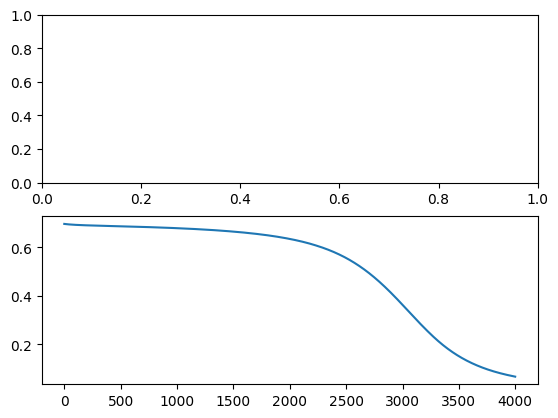

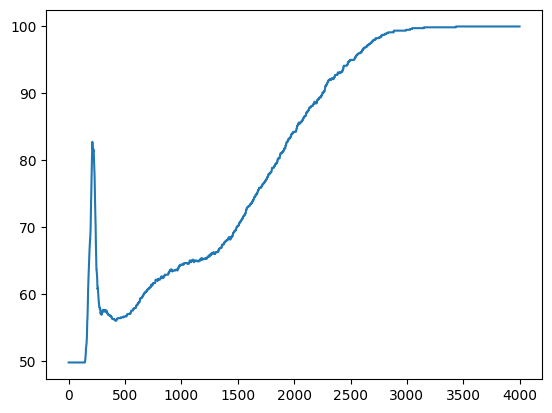

In [23]:
plt.figure(dpi=1000)
plt.subplots(2,1)
plt.plot(l)
plt.subplots(1,1)
plt.plot(a)